In [1]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import MulticlassAccuracy
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [2]:
rawX, rawY = make_classification(n_samples= 15_00_000, random_state= 42, n_classes= 5, n_features= 42, n_informative= 42, n_redundant= 0, n_repeated= 0, n_clusters_per_class= 1)
rawX, rawY

(array([[-0.11626242,  2.36325879,  3.16574934, ...,  0.3800754 ,
         -5.37594837,  2.50398809],
        [-0.15791859,  5.84170156, -1.45071831, ...,  4.02482091,
         -1.28767383,  0.42884419],
        [ 3.06830337,  4.26610504, -1.94232376, ..., -2.87321222,
          0.42863244,  3.02719934],
        ...,
        [-1.78333182,  6.18701361, -5.93541118, ...,  0.47993129,
          5.66002339, -5.69493966],
        [-0.71666492,  3.87785319,  6.48007411, ...,  1.84540294,
         -2.86459631, -6.57886359],
        [ 3.0325503 , -3.37994863, -1.6073849 , ...,  0.038248  ,
          3.97198745, -1.21789656]], shape=(1500000, 42)),
 array([3, 2, 3, ..., 1, 2, 3], shape=(1500000,)))

In [3]:
scaller = StandardScaler()
rawX = scaller.fit_transform(rawX)

In [4]:
XTrain, XRemain, yTrain, yRemain = train_test_split(rawX, rawY, stratify= rawY, random_state= 67, test_size= 5_00_000)

XTrain, XRemain, yTrain, yRemain

(array([[ 0.31798821, -1.26004698,  1.75784274, ..., -0.38106088,
         -0.41578324, -0.85451876],
        [-0.14180253, -0.35436949,  0.71356241, ..., -0.09361832,
          0.61306927,  1.0112018 ],
        [-0.25190524, -1.3127911 ,  1.82360512, ..., -0.28423751,
          0.18912915, -0.46069247],
        ...,
        [-1.84406802, -1.31811035,  0.78585119, ..., -0.24307931,
         -0.53300801, -0.08909855],
        [-0.7785332 , -0.20865431,  2.60484849, ...,  1.99369371,
         -0.00578942,  0.19402694],
        [-0.31886295, -0.17754939, -0.28794395, ..., -0.94778204,
         -2.09295922, -0.22685871]], shape=(1000000, 42)),
 array([[ 0.40518251, -0.72808864, -1.12874367, ...,  0.88727249,
         -0.53198924,  0.40388702],
        [-0.5805926 , -1.23848648,  0.73621648, ..., -0.04691902,
         -1.12982504,  2.0172108 ],
        [-0.94813181, -0.59723525, -0.84808334, ..., -1.83546735,
         -0.05921975, -0.58195933],
        ...,
        [-0.15414812, -0.83314362

In [5]:
XEval, XTest, yEval, yTest = train_test_split(XRemain, yRemain, stratify= yRemain, random_state= 67, test_size= 0.5)
XEval, XTest, yEval, yTest

(array([[-0.09518341,  0.70593588,  0.60595513, ...,  0.90155587,
          0.59669574, -1.20576841],
        [-0.33227432,  0.87129786, -0.14890134, ..., -0.26263515,
          0.08163733, -0.46927746],
        [ 0.60781847, -1.09097506,  1.04495985, ...,  1.48339512,
         -0.91134605,  0.19882515],
        ...,
        [-0.20510052,  0.28053529,  0.25596144, ..., -1.01579344,
         -1.36693024, -1.70771464],
        [ 0.26999903,  0.54778619, -0.50981005, ..., -0.15765187,
          1.17470729,  2.86736925],
        [ 0.59473898,  1.78839925,  1.49555726, ..., -0.1488353 ,
         -0.02637676,  0.31924614]], shape=(250000, 42)),
 array([[ 0.82061549,  1.29014475,  0.78614017, ..., -0.64206822,
          1.48450665, -0.91922735],
        [ 1.81074945, -0.10837754,  1.45341347, ...,  0.26191023,
          0.87075001,  0.65593452],
        [ 0.88926796, -0.0746919 ,  0.08265926, ...,  1.43817375,
          0.74172888, -0.08103091],
        ...,
        [ 0.43982703,  0.29047781,

In [6]:
class ToyDataset(Dataset):

    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return torch.tensor(self.features[index], dtype= torch.float32), torch.tensor(self.labels[index], dtype = torch.long)

trainDataset = ToyDataset(XTrain, yTrain)
evalDataset = ToyDataset(XEval, yEval)
testDataset = ToyDataset(XTest, yTest)

len(trainDataset), len(evalDataset), len(testDataset)

(1000000, 250000, 250000)

In [7]:
trainLoader = DataLoader(trainDataset, batch_size= 32, shuffle= True)

evalLoader = DataLoader(evalDataset, batch_size= len(evalDataset), shuffle= False)

testLoader = DataLoader(testDataset, batch_size= len(testDataset), shuffle= False)


In [8]:
class Model(nn.Module):

    def __init__(self, features):
        super().__init__()

        self.neuralNet = nn.Sequential(
            nn.Linear(features, 42),
            nn.ReLU(),
            nn.Linear(42, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 5)
        )

    def forward(self, X):
        return self.neuralNet(X)
    


In [9]:
model = Model(XTrain.shape[1])

In [10]:
trainLossHist = []
trainAccHist = []

evalLossHist = []
evalAccHist = []

In [19]:
lossFunc = nn.CrossEntropyLoss()

alpha = 0.02

optimizer = torch.optim.SGD(model.parameters(), lr= alpha)

accuracy = MulticlassAccuracy(num_classes= 5)

In [12]:
torch.set_num_threads(10)

In [20]:
epochs = 20

for epoch in range(epochs):

    lossMean = 0
    accMean = 0

    for X, y in trainLoader:

        yHat = model(X)
        loss = lossFunc(yHat, y)
        lossMean += loss.item()
        yHat = torch.argmax(yHat, dim=1)
        accMean += accuracy(yHat, y).item()
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

    lossMean = lossMean / len(trainLoader)
    accMean = accMean / len(trainLoader)
    
    model.eval()
    for X, y in evalLoader:
        
        with torch.no_grad():
            yHat = model(X)
            loss = lossFunc(yHat, y)
            yHat = torch.argmax(yHat, dim= 1)
            acc = accuracy(yHat, y)

            trainLossHist.append(lossMean)
            trainAccHist.append(accMean)

            evalLossHist.append(loss.item())
            evalAccHist.append(acc.item())

            print(
                    f"Epoch: {epoch + 1}, "
                    f"train loss: {lossMean}, "
                    f"train accuracy: {accMean * 100:.2f}% | "
                    f"evaluation loss: {loss.item()}, "
                    f"evaluation accuracy: {acc.item() * 100:.2f}%"
                )
    
    model.train()


Epoch: 1, train loss: 0.05775594626370072, train accuracy: 99.18% | evaluation loss: 0.060063526034355164, evaluation accuracy: 99.16%
Epoch: 2, train loss: 0.05755032785692811, train accuracy: 99.19% | evaluation loss: 0.0599675327539444, evaluation accuracy: 99.16%
Epoch: 3, train loss: 0.05745533319370449, train accuracy: 99.19% | evaluation loss: 0.060063980519771576, evaluation accuracy: 99.16%
Epoch: 4, train loss: 0.05738078124652803, train accuracy: 99.20% | evaluation loss: 0.06010055914521217, evaluation accuracy: 99.16%
Epoch: 5, train loss: 0.05732737254463136, train accuracy: 99.20% | evaluation loss: 0.06014742702245712, evaluation accuracy: 99.16%
Epoch: 6, train loss: 0.05725785144740343, train accuracy: 99.19% | evaluation loss: 0.06025613099336624, evaluation accuracy: 99.16%
Epoch: 7, train loss: 0.05717600154404342, train accuracy: 99.20% | evaluation loss: 0.060469672083854675, evaluation accuracy: 99.16%
Epoch: 8, train loss: 0.05712494965688884, train accuracy: 9

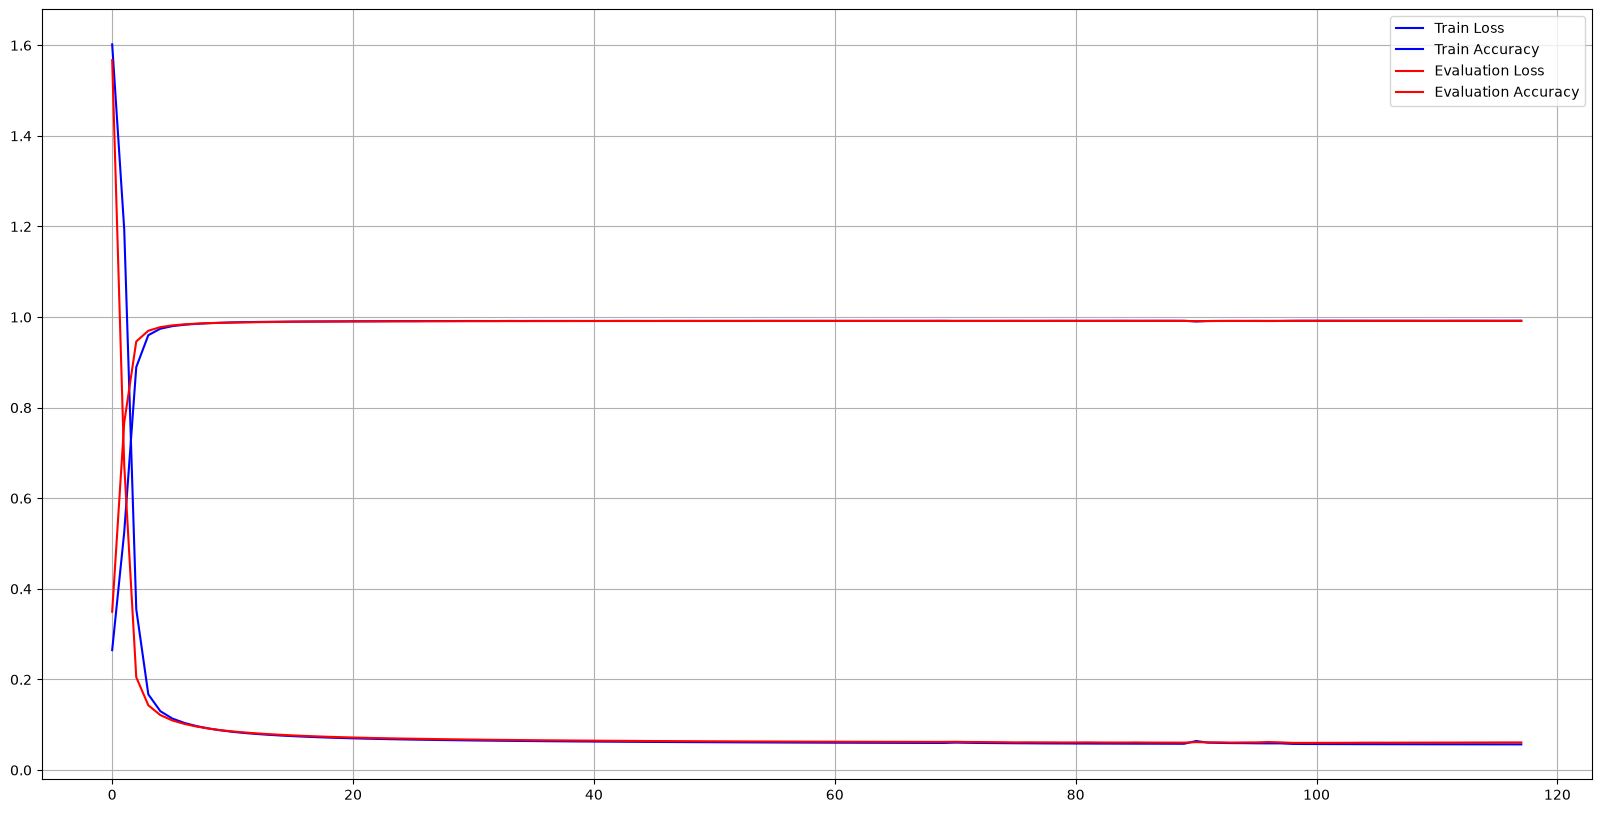

In [21]:
plt.figure(figsize=(20, 10))
plt.grid(True)
plt.plot(trainLossHist, c= "b", label = "Train Loss")
plt.plot(trainAccHist, c = "b", label = "Train Accuracy")
plt.plot(evalLossHist, c = "r", label = "Evaluation Loss")
plt.plot(evalAccHist, c = "r", label = "Evaluation Accuracy")
plt.legend(loc="best")
plt.show()